<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Main questions
1. What exactly changes across regimes
2. Are Deep Models actually necessary and better than benchmarks
3. How to handle temporal dependencies
4. How many regimes actually exist in the data

TODO ADD factors to the dataset

In [5]:
data = pd.read_csv(
    "/content/drive/MyDrive/data_dipl_proj/merged_100_portfolios_ff5_daily.csv",
    parse_dates=True,
    low_memory=False,
).set_index("Date")

SENTINEL_VALUES = [-99.99, -999, -999.0, -100, -100.0]
data = (
    data.replace(r'^\s*$', np.nan, regex=True)
        .replace({v: np.nan for v in SENTINEL_VALUES})
        .apply(pd.to_numeric, errors="coerce")
        / 100
)
data.index = pd.to_datetime(data.index)

FACTOR_COLS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
PORTFOLIO_COLS = [c for c in data.columns if c not in FACTOR_COLS]

In [6]:
def chronological_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    i1, i2 = int(n * train_frac), int(n * (train_frac + val_frac))
    return df.iloc[:i1].copy(), df.iloc[i1:i2].copy(), df.iloc[i2:].copy()


train_raw, val_raw, test_raw = chronological_split(data)

mask_train = train_raw.notna().astype(np.float32)
mask_val   = val_raw.notna().astype(np.float32)
mask_test  = test_raw.notna().astype(np.float32)

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw.fillna(0)),
                             index=train_raw.index, columns=train_raw.columns)
val_scaled   = pd.DataFrame(scaler.transform(val_raw.fillna(0)),
                             index=val_raw.index,   columns=val_raw.columns)
test_scaled  = pd.DataFrame(scaler.transform(test_raw.fillna(0)),
                             index=test_raw.index,  columns=test_raw.columns)

train_masked = train_scaled.where(mask_train.astype(bool))
val_masked   = val_scaled.where(mask_val.astype(bool))
test_masked  = test_scaled.where(mask_test.astype(bool))

print("Train:", train_raw.index.min().date(), "->", train_raw.index.max().date(), train_raw.shape)
print("Val:  ", val_raw.index.min().date(),   "->", val_raw.index.max().date(),   val_raw.shape)
print("Test: ", test_raw.index.min().date(),  "->", test_raw.index.max().date(),  test_raw.shape)

Train: 1963-07-01 -> 2007-02-16 (10983, 106)
Val:   2007-02-20 -> 2016-06-22 (2353, 106)
Test:  2016-06-23 -> 2025-10-31 (2354, 106)


In [7]:
def _log_emission(port_ret, factor_ret, obs_mask, intercepts, loadings, resid_std):
    T, K = port_ret.shape[0], intercepts.shape[0]
    resid_var = np.maximum(resid_std ** 2, 1e-8)
    log_emit = np.zeros((T, K))
    for k in range(K):
        pred   = intercepts[k] + factor_ret @ loadings[k].T
        sq_err = (port_ret - pred) ** 2
        ll     = -0.5 * (np.log(2 * np.pi * resid_var) + sq_err / resid_var)
        ll[~obs_mask] = 0.0
        log_emit[:, k] = ll.sum(axis=1)
    return log_emit


def _forward_backward(log_emit, pi0, A):
    T, K   = log_emit.shape
    log_pi = np.log(np.clip(pi0, 1e-12, 1))
    log_A  = np.log(np.clip(A,   1e-12, 1))

    alpha = np.zeros((T, K))
    alpha[0] = log_pi + log_emit[0]
    for t in range(1, T):
        alpha[t] = log_emit[t] + logsumexp(alpha[t-1, :, None] + log_A, axis=0)
    log_lik = logsumexp(alpha[-1])

    beta = np.zeros((T, K))
    for t in range(T - 2, -1, -1):
        beta[t] = logsumexp(log_A + log_emit[t+1] + beta[t+1], axis=1)

    log_gamma = alpha + beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    gamma = np.exp(log_gamma)

    xi = np.zeros((T - 1, K, K))
    for t in range(T - 1):
        lp  = alpha[t, :, None] + log_A + log_emit[t+1] + beta[t+1]
        lp -= logsumexp(lp)
        xi[t] = np.exp(lp)

    return gamma, xi, log_lik


def _m_step_regression(port_ret, design, obs_mask, gamma, K, ridge=1e-5):
    P, F = port_ret.shape[1], design.shape[1] - 1
    intercepts = np.zeros((K, P))
    loadings   = np.zeros((K, P, F))
    for k in range(K):
        w = np.sqrt(np.clip(gamma[:, k], 1e-12, None))
        for p in range(P):
            obs = obs_mask[:, p]
            if obs.sum() < F + 2:
                continue
            Xw   = design[obs] * w[obs, None]
            yw   = port_ret[obs, p] * w[obs]
            coef = np.linalg.solve(Xw.T @ Xw + ridge * np.eye(F + 1), Xw.T @ yw)
            intercepts[k, p] = coef[0]
            loadings[k, p]   = coef[1:]
    return intercepts, loadings


def _m_step_resid_std(port_ret, factor_ret, obs_mask, gamma, intercepts, loadings):
    K, P = intercepts.shape
    sse  = np.zeros(P)
    for k in range(K):
        pred   = intercepts[k] + factor_ret @ loadings[k].T
        sq_err = (port_ret - pred) ** 2
        sq_err[~obs_mask] = 0.0
        sse += (gamma[:, k, None] * sq_err).sum(axis=0)
    return np.sqrt(np.maximum(sse / np.maximum(obs_mask.sum(0), 1), 1e-8))


def _m_step_markov(gamma, xi, sticky=50.0):
    pi0 = np.clip(gamma[0], 1e-12, None)
    pi0 /= pi0.sum()
    K = gamma.shape[1]
    A = xi.sum(0) + sticky * np.eye(K)
    A /= A.sum(1, keepdims=True)
    return pi0, A

In [8]:
def fit_hmm_factor(port_ret, factor_ret, obs_mask, K=3,
                   max_iter=50, tol=1e-4, ridge=1e-5, sticky=50.0, seed=0):
    T     = port_ret.shape[0]
    design = np.column_stack([np.ones(T), factor_ret])
    rng   = np.random.default_rng(seed)
    gamma = rng.dirichlet(np.ones(K), size=T)
    pi0   = np.full(K, 1.0 / K)
    A     = np.where(np.eye(K), 0.95, 0.05 / (K - 1))

    intercepts, loadings = _m_step_regression(port_ret, design, obs_mask, gamma, K, ridge)
    resid_std = _m_step_resid_std(port_ret, factor_ret, obs_mask, gamma, intercepts, loadings)

    prev_ll = -np.inf
    for _ in range(max_iter):
        log_emit = _log_emission(port_ret, factor_ret, obs_mask, intercepts, loadings, resid_std)
        gamma, xi, ll = _forward_backward(log_emit, pi0, A)
        pi0, A        = _m_step_markov(gamma, xi, sticky)
        intercepts, loadings = _m_step_regression(port_ret, design, obs_mask, gamma, K, ridge)
        resid_std = _m_step_resid_std(port_ret, factor_ret, obs_mask, gamma, intercepts, loadings)
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    return dict(ll=ll, pi0=pi0, A=A, gamma=gamma,
                states=gamma.argmax(1), intercepts=intercepts,
                loadings=loadings, resid_std=resid_std)


def bic(ll, K, P, F, T):
    n_params = (K - 1) + K * (K - 1) + K * P * (1 + F) + P
    return -2 * ll + n_params * np.log(T)

In [9]:
port_np   = train_masked[PORTFOLIO_COLS].fillna(0).to_numpy(dtype=np.float64)
factor_np = train_masked[FACTOR_COLS].to_numpy(dtype=np.float64)
mask_np   = mask_train[PORTFOLIO_COLS].to_numpy(dtype=bool)

valid     = np.all(np.isfinite(factor_np), axis=1)
port_np, factor_np, mask_np = port_np[valid], factor_np[valid], mask_np[valid]
plot_idx  = train_masked.index[valid]

results_A, models_A = [], {}
for K in [2, 3]:
    best = max(
        (fit_hmm_factor(port_np, factor_np, mask_np, K=K, seed=s, sticky= 200.0) for s in range(5)),
        key=lambda m: m["ll"]
    )
    b = bic(best["ll"], K, len(PORTFOLIO_COLS), len(FACTOR_COLS), port_np.shape[0])
    results_A.append({"K": K, "log_likelihood": best["ll"], "BIC": b})
    models_A[K] = best

results_A_df = pd.DataFrame(results_A).sort_values("BIC").reset_index(drop=True)
best_K_A     = int(results_A_df.iloc[0]["K"])
model_A      = models_A[best_K_A]
print(results_A_df)
print(f"Selected K={best_K_A}")

   K  log_likelihood           BIC
0  3  -865993.531759  1.752531e+06
1  2  -875264.854694  1.764514e+06
Selected K=3


In [10]:
N_PCA = 5
pca = PCA(n_components=N_PCA, random_state=0)
train_pca = pca.fit_transform(train_scaled[PORTFOLIO_COLS].fillna(0))
test_pca  = pca.transform(test_scaled[PORTFOLIO_COLS].fillna(0))
print(f"PCA top-{N_PCA} explained variance: {pca.explained_variance_ratio_.sum():.2%}")


def fit_pca_hmm(train_pca, K, sticky_diag=0.9, n_iter=200, seed=0):
    off = (1 - sticky_diag) / (K - 1)
    init_transmat = np.where(np.eye(K), sticky_diag, off)

    m = hmm.GaussianHMM(
        n_components=K,
        covariance_type="full",
        n_iter=n_iter,
        tol=1e-4,
        init_params="mc",   # initialise means and covars, NOT transmat
        params="tmc",       # learn all params including transmat during EM
        random_state=seed,
    )
    m.transmat_ = init_transmat   # warm-start; EM will refine from here
    m.fit(train_pca)
    return m


results_B, models_B = [], {}
for K in [2, 3]:
    m = fit_pca_hmm(train_pca, K)
    train_ll = m.score(train_pca)
    test_ll  = m.score(test_pca)
    k_params = K**2 + K * N_PCA + K * N_PCA * (N_PCA + 1) // 2
    b = -2 * train_ll + k_params * np.log(len(train_pca))
    results_B.append({"K": K, "train_ll": train_ll, "test_ll": test_ll, "BIC": b})
    models_B[K] = m

results_B_df = pd.DataFrame(results_B).sort_values("BIC").reset_index(drop=True)
best_K_B     = int(results_B_df.iloc[0]["K"])
model_B      = models_B[best_K_B]
train_states_B = model_B.predict(train_pca)
print(results_B_df)
print(f"Selected K={best_K_B}")

PCA top-5 explained variance: 72.45%
   K       train_ll       test_ll            BIC
0  3 -102941.236161 -29871.259928  206524.455492
1  2 -104532.669249 -30741.298123  209474.719069
Selected K=3


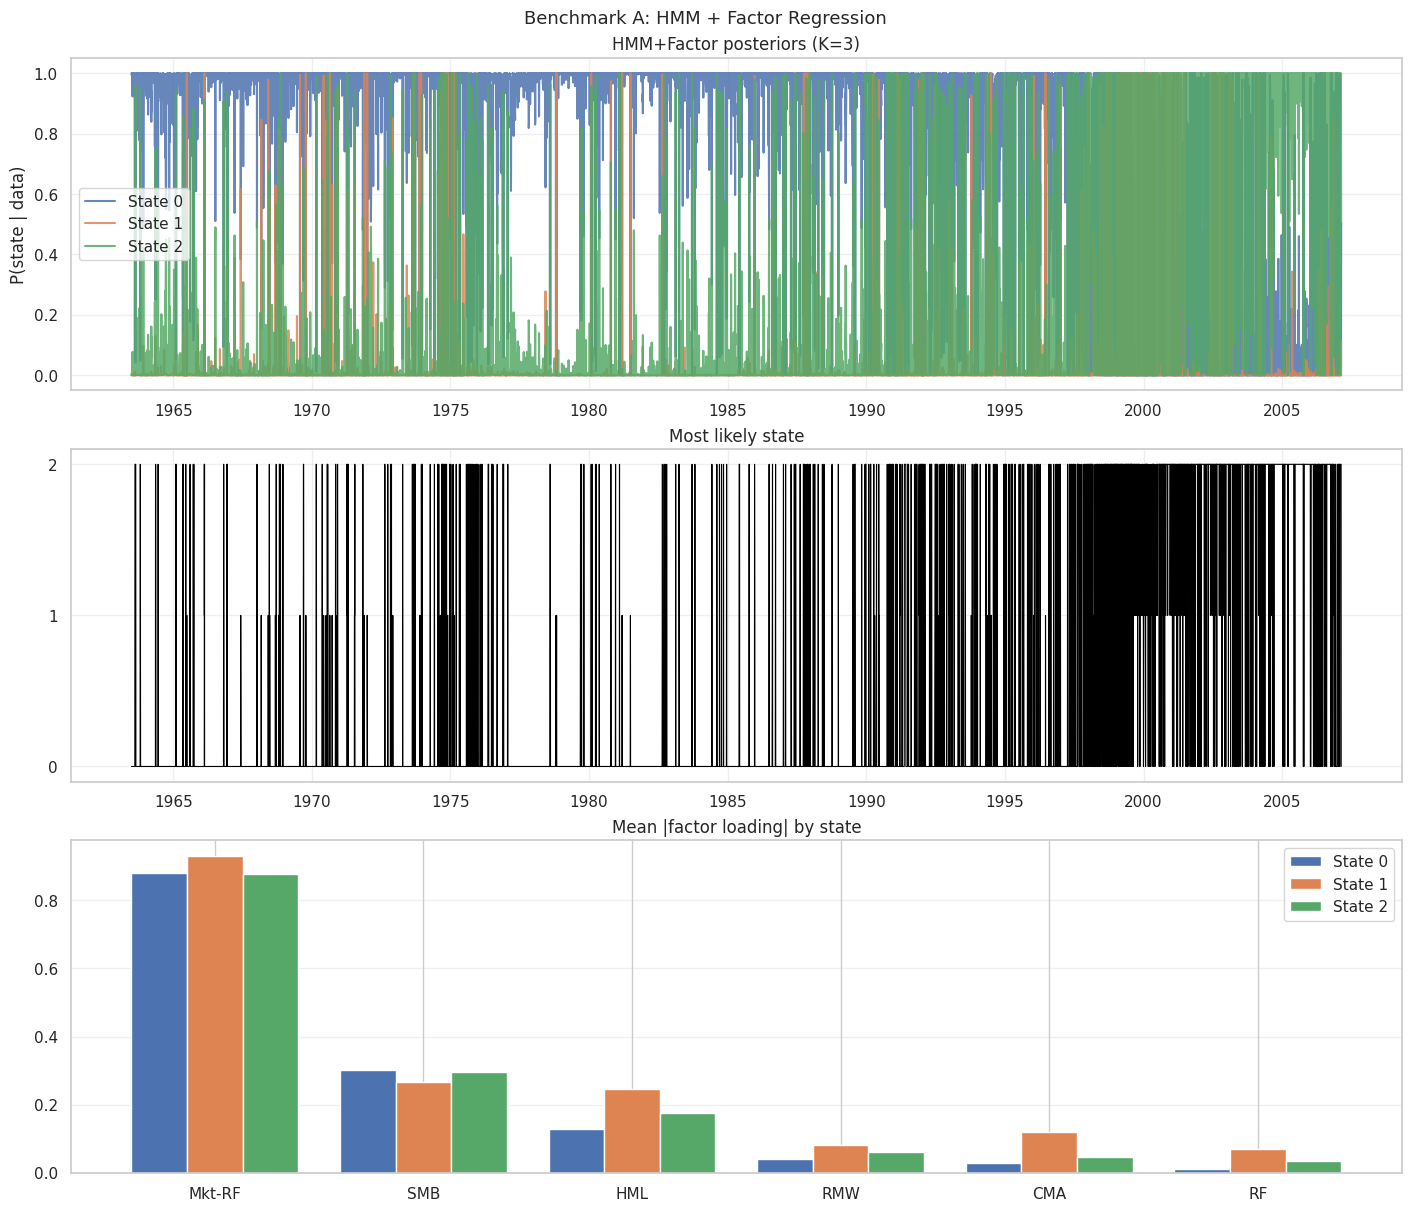

In [11]:
gamma_A  = model_A["gamma"]
states_A = model_A["states"]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

for k in range(best_K_A):
    axes[0].plot(plot_idx, gamma_A[:, k], label=f"State {k}", alpha=0.85)
axes[0].set_title(f"HMM+Factor posteriors (K={best_K_A})")
axes[0].set_ylabel("P(state | data)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(plot_idx, states_A, color="black", lw=0.8)
axes[1].set_yticks(range(best_K_A))
axes[1].set_title("Most likely state"); axes[1].grid(alpha=0.3)

mean_abs = np.abs(model_A["loadings"]).mean(axis=1)
x, w = np.arange(len(FACTOR_COLS)), 0.8 / best_K_A
for k in range(best_K_A):
    axes[2].bar(x + k * w, mean_abs[k], width=w, label=f"State {k}")
axes[2].set_xticks(x + w * (best_K_A - 1) / 2)
axes[2].set_xticklabels(FACTOR_COLS)
axes[2].set_title("Mean |factor loading| by state")
axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Benchmark A: HMM + Factor Regression", fontsize=13)
plt.show()

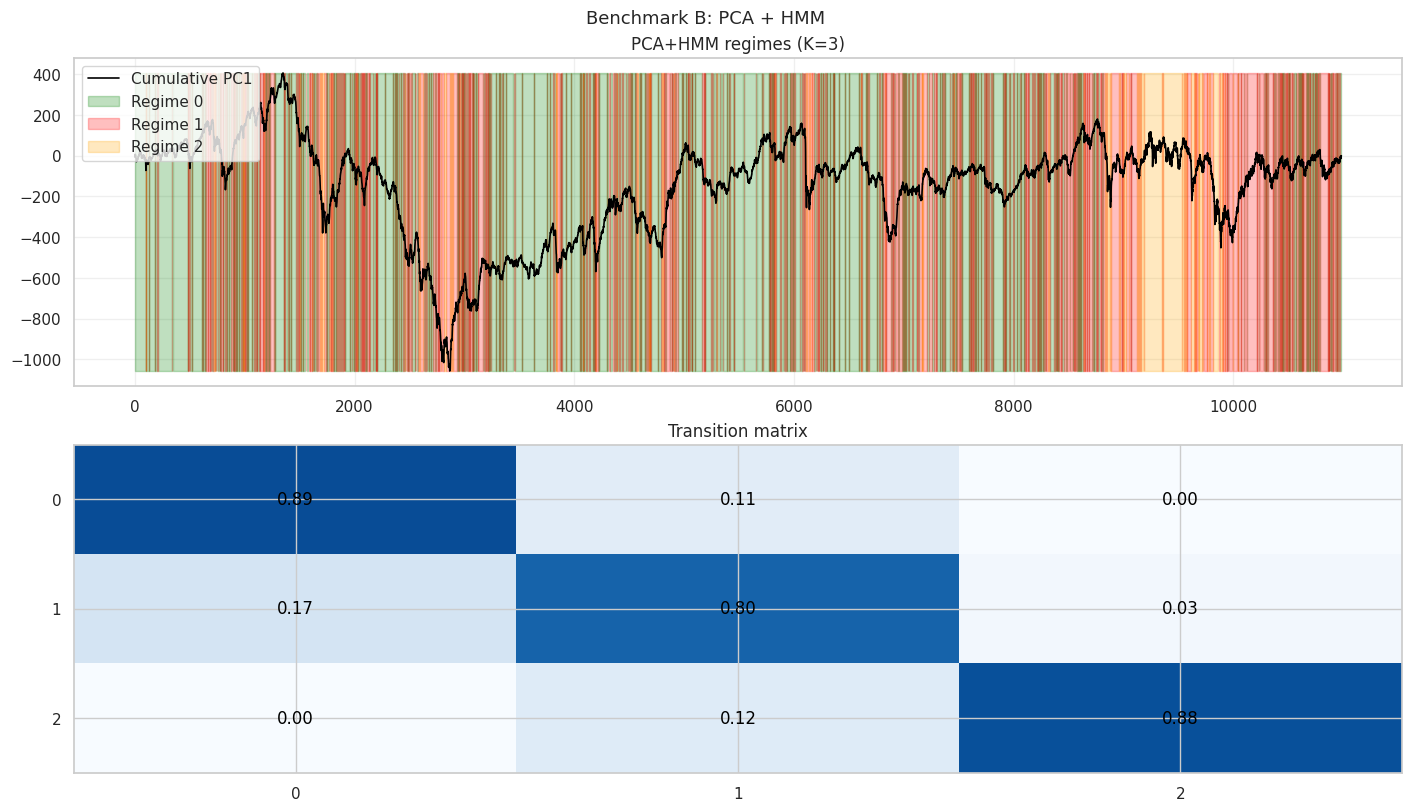

In [12]:
cum_pc1 = np.cumsum(train_pca[:, 0])
colors  = ["green", "red", "orange", "purple"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].plot(cum_pc1, color="black", lw=1.2, label="Cumulative PC1")
for k in range(best_K_B):
    axes[0].fill_between(range(len(train_states_B)),
                         cum_pc1.min(), cum_pc1.max(),
                         where=(train_states_B == k),
                         color=colors[k], alpha=0.25, label=f"Regime {k}")
axes[0].set_title(f"PCA+HMM regimes (K={best_K_B})")
axes[0].legend(loc="upper left"); axes[0].grid(alpha=0.3)

axes[1].imshow(model_B.transmat_, cmap="Blues", aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Transition matrix")
axes[1].set_xticks(range(best_K_B)); axes[1].set_yticks(range(best_K_B))
for i in range(best_K_B):
    for j in range(best_K_B):
        axes[1].text(j, i, f"{model_B.transmat_[i,j]:.2f}",
                     ha="center", va="center", color="black")

plt.suptitle("Benchmark B: PCA + HMM", fontsize=13)
plt.show()

In [13]:
def nll_per_dim_hmm_factor(model, port_ret, factor_ret, obs_mask):
    """
    Average negative log-likelihood per observed dimension per timestep.
    Marginalises over states using forward-backward.
    """
    log_emit = _log_emission(port_ret, factor_ret, obs_mask,
                             model["intercepts"], model["loadings"], model["resid_std"])
    _, _, ll = _forward_backward(log_emit, model["pi0"], model["A"])
    total_observed = obs_mask.sum()
    return -ll / total_observed


def nll_per_dim_pca_hmm(model, port_df, pca, n_pca):
    """
    Average negative log-likelihood per PC dimension per timestep.
    Uses exact Gaussian mixture LL from hmmlearn.
    """
    pc = pca.transform(port_df[PORTFOLIO_COLS].fillna(0).to_numpy(dtype=np.float64))
    ll = model.score(pc)           # total log-likelihood over sequence
    total_dims = len(pc) * n_pca
    return -ll / total_dims


def score_splits(model_a, model_b, pca, n_pca):
    rows = []
    for split, port_df, mask_df in [
        ("val",  val_masked,  mask_val),
        ("test", test_masked, mask_test),
    ]:
        # HMM+Factor arrays
        p  = port_df[PORTFOLIO_COLS].fillna(0).to_numpy(dtype=np.float64)
        f  = port_df[FACTOR_COLS].to_numpy(dtype=np.float64)
        m  = mask_df[PORTFOLIO_COLS].to_numpy(dtype=bool)
        ok = np.all(np.isfinite(f), axis=1)
        p, f, m = p[ok], f[ok], m[ok]

        nll_a = nll_per_dim_hmm_factor(model_a, p, f, m)
        nll_b = nll_per_dim_pca_hmm(model_b, port_df, pca, n_pca)

        rows.append({"split": split, "HMM_Factor_nll_dim": nll_a, "PCA_HMM_nll_dim": nll_b})

    return pd.DataFrame(rows)


scores_df = score_splits(model_A, model_B, pca, N_PCA)
print(scores_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


split  HMM_Factor_nll_dim  PCA_HMM_nll_dim
  val            0.868539         2.362759
 test            1.150339         2.537927


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [14]:
mkt_train = train_masked["Mkt-RF"].to_numpy(dtype=np.float64)[valid]

regime_stats = {}
for k in range(best_K_A):
    idx = model_A["states"] == k
    regime_stats[k] = {
        "mean_mkt":  mkt_train[idx].mean(),
        "std_mkt":   mkt_train[idx].std(),
        "n_days":    idx.sum(),
        "pct":       idx.mean(),
    }

stats_df = pd.DataFrame(regime_stats).T.sort_values("mean_mkt", ascending=False)
stats_df.index.name = "state"

label_map = {}
labels    = ["bull", "bear", "sideways"]
for rank, state in enumerate(stats_df.index):
    label_map[int(state)] = labels[rank] if rank < len(labels) else f"state_{rank}"

stats_df["label"] = [label_map[int(i)] for i in stats_df.index]
print(stats_df.round(4))

# Attach labels to state sequence
state_labels_A = np.array([label_map[s] for s in model_A["states"]])

       mean_mkt  std_mkt  n_days     pct     label
state                                             
2        0.0841   1.1348  2326.0  0.2118      bull
1        0.0255   1.6742   328.0  0.0299      bear
0       -0.0245   0.9198  8329.0  0.7584  sideways


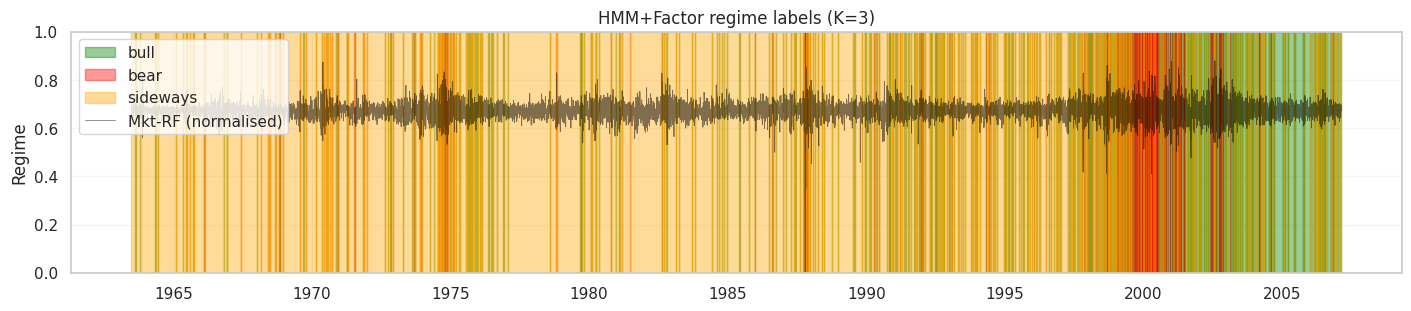

In [15]:
fig, ax = plt.subplots(figsize=(14, 3), constrained_layout=True)

color_map = {"bull": "green", "bear": "red", "sideways": "orange"}
for label, color in color_map.items():
    mask = state_labels_A == label
    ax.fill_between(plot_idx, 0, 1, where=mask,
                    color=color, alpha=0.4, label=label, transform=ax.get_xaxis_transform())

ax.plot(plot_idx, (mkt_train - mkt_train.min()) / (mkt_train.max() - mkt_train.min()),
        color="black", lw=0.6, alpha=0.5, label="Mkt-RF (normalised)")

ax.set_title(f"HMM+Factor regime labels (K={best_K_A})")
ax.set_ylabel("Regime"); ax.set_ylim(0, 1)
ax.legend(loc="upper left"); ax.grid(alpha=0.2)
plt.show()

In [16]:
train_nll_a = -model_A["ll"] / mask_np.sum()
train_nll_b = -model_B.score(train_pca) / (len(train_pca) * N_PCA)

comparison_df = pd.DataFrame([
    {
        "model":        "HMM+Factor",
        "K":            best_K_A,
        "train_nll/dim": train_nll_a,
        "val_nll/dim":   scores_df.loc[scores_df.split == "val",  "HMM_Factor_nll_dim"].item(),
        "test_nll/dim":  scores_df.loc[scores_df.split == "test", "HMM_Factor_nll_dim"].item(),
        "n_params":      (best_K_A - 1) + best_K_A * (best_K_A - 1)
                         + best_K_A * len(PORTFOLIO_COLS) * (1 + len(FACTOR_COLS))
                         + len(PORTFOLIO_COLS),
    },
    {
        "model":        "PCA+HMM",
        "K":            best_K_B,
        "train_nll/dim": train_nll_b,
        "val_nll/dim":   scores_df.loc[scores_df.split == "val",  "PCA_HMM_nll_dim"].item(),
        "test_nll/dim":  scores_df.loc[scores_df.split == "test", "PCA_HMM_nll_dim"].item(),
        "n_params":      best_K_B**2 + best_K_B * N_PCA + best_K_B * N_PCA * (N_PCA + 1) // 2,
    },
])

print(comparison_df.to_string(index=False))

     model  K  train_nll/dim  val_nll/dim  test_nll/dim  n_params
HMM+Factor  3       0.790661     0.868539      1.150339      2208
   PCA+HMM  3       1.874556     2.362759      2.537927        69


splitting, scaling data

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

In [17]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader

In [18]:
window_size = 100
batch_size  = 128

def create_windows(data_np, window_size):
    arr = np.array([data_np[i:i+window_size] for i in range(len(data_np) - window_size + 1)])
    return torch.tensor(arr, dtype=torch.float32)

X_train = create_windows(train_scaled.to_numpy(dtype=np.float32), window_size)
X_val   = create_windows(val_scaled.to_numpy(dtype=np.float32),   window_size)
X_test  = create_windows(test_scaled.to_numpy(dtype=np.float32),  window_size)

train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=batch_size, shuffle=False)

print("Train windows:", X_train.shape)
print("Val windows:  ", X_val.shape)
print("Test windows: ", X_test.shape)

Train windows: torch.Size([10884, 100, 106])
Val windows:   torch.Size([2254, 100, 106])
Test windows:  torch.Size([2255, 100, 106])


In [19]:
def forward_backward(log_emit, init_logits, trans_logits):
    # log_emit: (B, T, K)
    B, T, K = log_emit.shape
    log_pi = F.log_softmax(init_logits, dim=0)       # (K,)
    log_A  = F.log_softmax(trans_logits, dim=1)      # (K, K)

    alpha = [log_pi + log_emit[:, 0, :]]             # (B, K)
    for t in range(1, T):
        a = torch.logsumexp(alpha[-1].unsqueeze(2) + log_A, dim=1) + log_emit[:, t, :]
        alpha.append(a)
    alpha = torch.stack(alpha, dim=1)                # (B, T, K)

    beta = [torch.zeros(B, K, device=log_emit.device)]
    for t in range(T - 2, -1, -1):
        b = torch.logsumexp(log_A + log_emit[:, t+1, :].unsqueeze(1) + beta[0].unsqueeze(1), dim=2)
        beta.insert(0, b)
    beta = torch.stack(beta, dim=1)                  # (B, T, K)

    log_Z     = torch.logsumexp(alpha[:, -1, :], dim=1, keepdim=True).unsqueeze(1)
    gamma     = torch.exp(alpha + beta - log_Z)      # (B, T, K)

    xi = None
    if T > 1:
        xi_list = []
        for t in range(T - 1):
            lp = (alpha[:, t, :].unsqueeze(2) + log_A
                  + log_emit[:, t+1, :].unsqueeze(1) + beta[:, t+1, :].unsqueeze(1)
                  - log_Z)
            xi_list.append(torch.exp(lp))
        xi = torch.stack(xi_list, dim=1)             # (B, T-1, K, K)

    log_lik = torch.logsumexp(alpha[:, -1, :], dim=1)  # (B,)
    return gamma, xi, log_lik

In [20]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(),
        )
        self.mu     = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        B, T, D = x.shape
        h = self.net(x.reshape(B * T, D))
        return self.mu(h).view(B, T, -1), self.logvar(h).view(B, T, -1)


class Decoder(nn.Module):
    def __init__(self, latent_dim, num_states, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + num_states, hidden_dim), nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z, gamma):
        return self.net(torch.cat([z, gamma], dim=-1))


class HMMVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_states):
        super().__init__()
        self.num_states = num_states
        self.latent_dim = latent_dim

        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, num_states, hidden_dim, input_dim)

        self.init_logits  = nn.Parameter(torch.zeros(num_states))

        sticky = torch.full((num_states, num_states), -2.0)
        sticky.fill_diagonal_(2.0)
        self.trans_logits = nn.Parameter(sticky)

        spread = torch.zeros(num_states, latent_dim)
        for k in range(num_states):
            spread[k, k % latent_dim] = 3.0
        self.state_mu     = nn.Parameter(spread)
        self.state_logvar = nn.Parameter(torch.zeros(num_states, latent_dim))

    def reparameterise(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def kl_to_states(self, mu, logvar):
        # returns (B, T, K)
        var_q  = torch.exp(logvar).unsqueeze(2)
        mu_q   = mu.unsqueeze(2)
        lv_q   = logvar.unsqueeze(2)
        var_p  = torch.exp(self.state_logvar).unsqueeze(0).unsqueeze(0)
        mu_p   = self.state_mu.unsqueeze(0).unsqueeze(0)
        lv_p   = self.state_logvar.unsqueeze(0).unsqueeze(0)
        return 0.5 * (lv_p - lv_q + (var_q + (mu_q - mu_p)**2) / var_p - 1.0).sum(-1)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        B, T, L    = z.shape

        log_emit = -self.kl_to_states(mu, logvar) * 5.0      # amplify state discrimination
        gamma, xi, log_Z = forward_backward(log_emit, self.init_logits, self.trans_logits)

        x_recon = self.decoder(
            z.reshape(B * T, L),
            gamma.detach().reshape(B * T, self.num_states),
        ).view(B, T, -1)

        return x_recon, mu, logvar, gamma, xi, log_Z

In [21]:
@torch.no_grad()
def reinit_state_priors_kmeans(model, loader, device, n_init=10):
    from sklearn.cluster import KMeans
    model.eval()
    mus = []
    for (x,) in loader:
        mu, _ = model.encoder(x.to(device))
        mus.append(mu.reshape(-1, model.latent_dim).cpu().numpy())
    mus = np.concatenate(mus, axis=0)

    km = KMeans(n_clusters=model.num_states, n_init=n_init, random_state=0)
    km.fit(mus)

    model.state_mu.data = torch.tensor(km.cluster_centers_, dtype=torch.float32).to(device)
    print("Re-anchored state priors to k-means centres")
    print("Centre norms:", np.linalg.norm(km.cluster_centers_, axis=1).round(3))

In [22]:
def hmm_vae_loss(x, x_recon, mu, logvar, gamma, xi, model, kl_weight):
    B, T, _ = x.shape

    recon  = F.mse_loss(x_recon, x, reduction='sum') / (B * T)

    kl_per_dim = model.kl_to_states(mu, logvar)          # (B, T, K)
    free_bits  = 0.5                                      # nats per dim, tune between 0.1–1.0
    kl_z = (gamma * torch.clamp(kl_per_dim, min=free_bits)).sum(dim=(1, 2)).mean() / T
    log_pi = F.log_softmax(model.init_logits, dim=0)
    init   = -(gamma[:, 0, :] * log_pi).sum(dim=1).mean()

    log_A  = F.log_softmax(model.trans_logits, dim=1)
    trans  = -(xi * log_A).sum(dim=(1, 2, 3)).mean() / (T - 1) if xi is not None else 0.0

    trans_probs  = F.softmax(model.trans_logits, dim=1)
    entropy_reg  = (trans_probs * torch.log(trans_probs + 1e-9)).sum()  # minimising this = maximising entropy

    return recon + kl_weight * (kl_z + init + trans) + 0.05 * entropy_reg

In [23]:
def train(model, train_loader, val_loader, epochs, device,
          kl_anneal_cycles=4, kl_ratio=0.5):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)   # was 1e-3
    total_steps  = epochs * len(train_loader)
    cycle_steps  = max(total_steps // kl_anneal_cycles, 1)
    ramp_steps   = max(int(cycle_steps * kl_ratio), 1)

    step = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for (x,) in train_loader:
            x          = x.to(device)
            kl_weight  = min((step % cycle_steps) / ramp_steps, 1.0)

            x_recon, mu, logvar, gamma, xi, _ = model(x)
            loss = hmm_vae_loss(x, x_recon, mu, logvar, gamma, xi, model, kl_weight)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            train_loss += loss.item()
            step += 1

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(device)
                x_recon, mu, logvar, gamma, xi, _ = model(x)
                val_loss += hmm_vae_loss(x, x_recon, mu, logvar, gamma, xi, model, kl_weight=1.0).item()

        print(f"Epoch {epoch+1:03d}/{epochs} | "
              f"train {train_loss/len(train_loader):.4f} | "
              f"val {val_loss/len(val_loader):.4f} | "
              f"kl_w {kl_weight:.2f}")

In [24]:
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_states = 3

model = HMMVAE(
    input_dim  = X_train.shape[-1],
    hidden_dim = 64,
    latent_dim = 10,
    num_states = num_states,
)

# Phase 1: warm up encoder (short, kl_weight stays low)
train(model, train_loader, val_loader, epochs=10, device=device,
      kl_anneal_cycles=1, kl_ratio=0.9)

# Re-anchor state priors to actual latent clusters
reinit_state_priors_kmeans(model, train_loader, device)

# Phase 2: full training
train(model, train_loader, val_loader, epochs=90, device=device,
      kl_anneal_cycles=2, kl_ratio=0.8)

Epoch 001/10 | train 87.4896 | val 136.9815 | kl_w 0.11
Epoch 002/10 | train 46.0449 | val 93.7811 | kl_w 0.22
Epoch 003/10 | train 44.9389 | val 84.6494 | kl_w 0.33
Epoch 004/10 | train 43.9894 | val 76.4882 | kl_w 0.44
Epoch 005/10 | train 41.4655 | val 70.7835 | kl_w 0.55
Epoch 006/10 | train 41.0741 | val 67.1509 | kl_w 0.67
Epoch 007/10 | train 39.8273 | val 57.1824 | kl_w 0.78
Epoch 008/10 | train 39.1886 | val 55.1237 | kl_w 0.89
Epoch 009/10 | train 39.2836 | val 53.6202 | kl_w 1.00
Epoch 010/10 | train 39.4022 | val 53.0974 | kl_w 1.00
Re-anchored state priors to k-means centres
Centre norms: [3.224 2.994 3.055]
Epoch 001/90 | train 32.9397 | val 62.6313 | kl_w 0.03
Epoch 002/90 | train 32.4311 | val 60.6732 | kl_w 0.06
Epoch 003/90 | train 32.0237 | val 57.8687 | kl_w 0.08
Epoch 004/90 | train 31.9927 | val 57.1371 | kl_w 0.11
Epoch 005/90 | train 31.9425 | val 55.2753 | kl_w 0.14
Epoch 006/90 | train 32.1248 | val 53.7471 | kl_w 0.17
Epoch 007/90 | train 32.3756 | val 53.132

In [25]:
model.eval()
with torch.no_grad():
    x_sample = X_train[:256].to(device)
    mu_s, logvar_s = model.encoder(x_sample)
    kl = model.kl_to_states(mu_s, logvar_s)
    print(f"mu std across batch:     {mu_s.std(dim=0).mean().item():.4f}")
    print(f"mean logvar:             {logvar_s.mean().item():.4f}")
    for k in range(model.num_states):
        print(f"mean KL state {k}:         {kl[:,:,k].mean().item():.4f}")


@torch.no_grad()
def infer_states(model, loader, device):
    model.eval()
    gammas = []
    for (x,) in loader:
        _, _, _, gamma, _, _ = model(x.to(device))
        gammas.append(gamma.cpu())
    flat = torch.cat(gammas, dim=0).reshape(-1, model.num_states)
    return flat.argmax(dim=1), flat


@torch.no_grad()
def nll_per_dim_hmmvae(model, loader, device, M=50):
    model.eval()
    total_ll, total_dims = 0.0, 0
    for (x,) in loader:
        x       = x.to(device)
        B, T, D = x.shape
        mu, logvar = model.encoder(x)
        q       = Normal(mu, torch.exp(0.5 * logvar))
        log_ws  = []
        for _ in range(M):
            z       = q.rsample()
            gamma, _, _ = forward_backward(
                -model.kl_to_states(mu, logvar) * 5.0,
                model.init_logits, model.trans_logits,
            )
            x_recon = model.decoder(
                z.reshape(B * T, -1),
                gamma.reshape(B * T, model.num_states),
            ).view(B, T, D)
            log_pi_k = F.log_softmax(model.init_logits, dim=0)
            log_p_z  = torch.stack([
                log_pi_k[k] + Normal(
                    model.state_mu[k], torch.exp(0.5 * model.state_logvar[k])
                ).log_prob(z).sum(-1)
                for k in range(model.num_states)
            ], dim=0).logsumexp(dim=0)
            log_p_x  = Normal(x_recon, torch.ones_like(x_recon)).log_prob(x).sum(-1)
            log_q_z  = q.log_prob(z).sum(-1)
            log_ws.append(log_p_x + log_p_z - log_q_z)
        elbo = torch.stack(log_ws, 0).logsumexp(0).sum().item() - math.log(M) * B * T
        total_ll   += elbo
        total_dims += B * T * D
    return -total_ll / total_dims


train_states, train_gamma = infer_states(model, train_loader, device)
test_states,  test_gamma  = infer_states(model, test_loader,  device)
print("Train state counts:", torch.bincount(train_states))
print("Test  state counts:", torch.bincount(test_states))

train_nll_vae = nll_per_dim_hmmvae(model, train_loader, device, M=50)
val_nll_vae   = nll_per_dim_hmmvae(model, val_loader,   device, M=50)
test_nll_vae  = nll_per_dim_hmmvae(model, test_loader,  device, M=50)

val_pca_hmm  = -model_B.score(pca.transform(val_scaled[PORTFOLIO_COLS].fillna(0).to_numpy(np.float64)))  / (len(val_scaled)  * N_PCA)
test_pca_hmm = -model_B.score(pca.transform(test_scaled[PORTFOLIO_COLS].fillna(0).to_numpy(np.float64))) / (len(test_scaled) * N_PCA)

comparison_df = comparison_df[comparison_df.model != "HMMVAE"] if "HMMVAE" in comparison_df.model.values else comparison_df
comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{
        "model":         "HMMVAE",
        "K":             model.num_states,
        "train_nll/dim": train_nll_vae,
        "val_nll/dim":   val_nll_vae,
        "test_nll/dim":  test_nll_vae,
        "n_params":      sum(p.numel() for p in model.parameters()),
    }])
], ignore_index=True)

comparison_df.loc[comparison_df.model == "PCA+HMM", "val_nll/dim"]  = val_pca_hmm
comparison_df.loc[comparison_df.model == "PCA+HMM", "test_nll/dim"] = test_pca_hmm

print(comparison_df.to_string(index=False))
print("\nNote: PCA+HMM scores a 5-dim PC target — not directly comparable to 106-dim models.")
print("Note: HMMVAE reports an IW-ELBO lower bound, not exact log-likelihood.")

mu std across batch:     0.2552
mean logvar:             -1.5647
mean KL state 0:         8.8738
mean KL state 1:         3.9690
mean KL state 2:         10.6299
Train state counts: tensor([  35486, 1032129,   20785])
Test  state counts: tensor([ 41564, 168844,  15092])
     model  K  train_nll/dim  val_nll/dim  test_nll/dim  n_params
HMM+Factor  3       0.790661     0.868539      1.150339      2208
   PCA+HMM  3       1.874556     2.362762      2.537915        69
    HMMVAE  3       1.109544     1.171959      1.233093     24326

Note: PCA+HMM scores a 5-dim PC target — not directly comparable to 106-dim models.
Note: HMMVAE reports an IW-ELBO lower bound, not exact log-likelihood.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


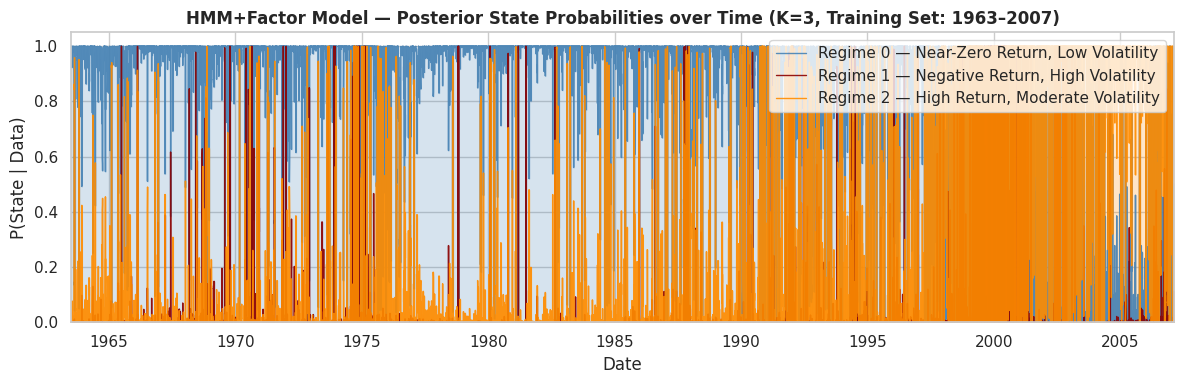

In [32]:
sns.set_theme(style="whitegrid")

gamma_A    = model_A["gamma"]
plot_index = plot_idx

fig, ax = plt.subplots(figsize=(12, 4))

for k, (color, label) in enumerate([
    ("steelblue",  "Regime 0 — Near-Zero Return, Low Volatility"),
    ("darkred",    "Regime 1 — Negative Return, High Volatility"),
    ("darkorange", "Regime 2 — High Return, Moderate Volatility"),
]):
    ax.plot(plot_index, gamma_A[:, k], label=label, color=color, alpha=0.9, lw=1)
    ax.fill_between(plot_index, 0, gamma_A[:, k], color=color, alpha=0.22)

ax.set_title("HMM+Factor Model — Posterior State Probabilities over Time (K=3, Training Set: 1963–2007)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("P(State | Data)")
ax.set_xlabel("Date")
ax.set_xlim(plot_index.min(), plot_index.max())
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

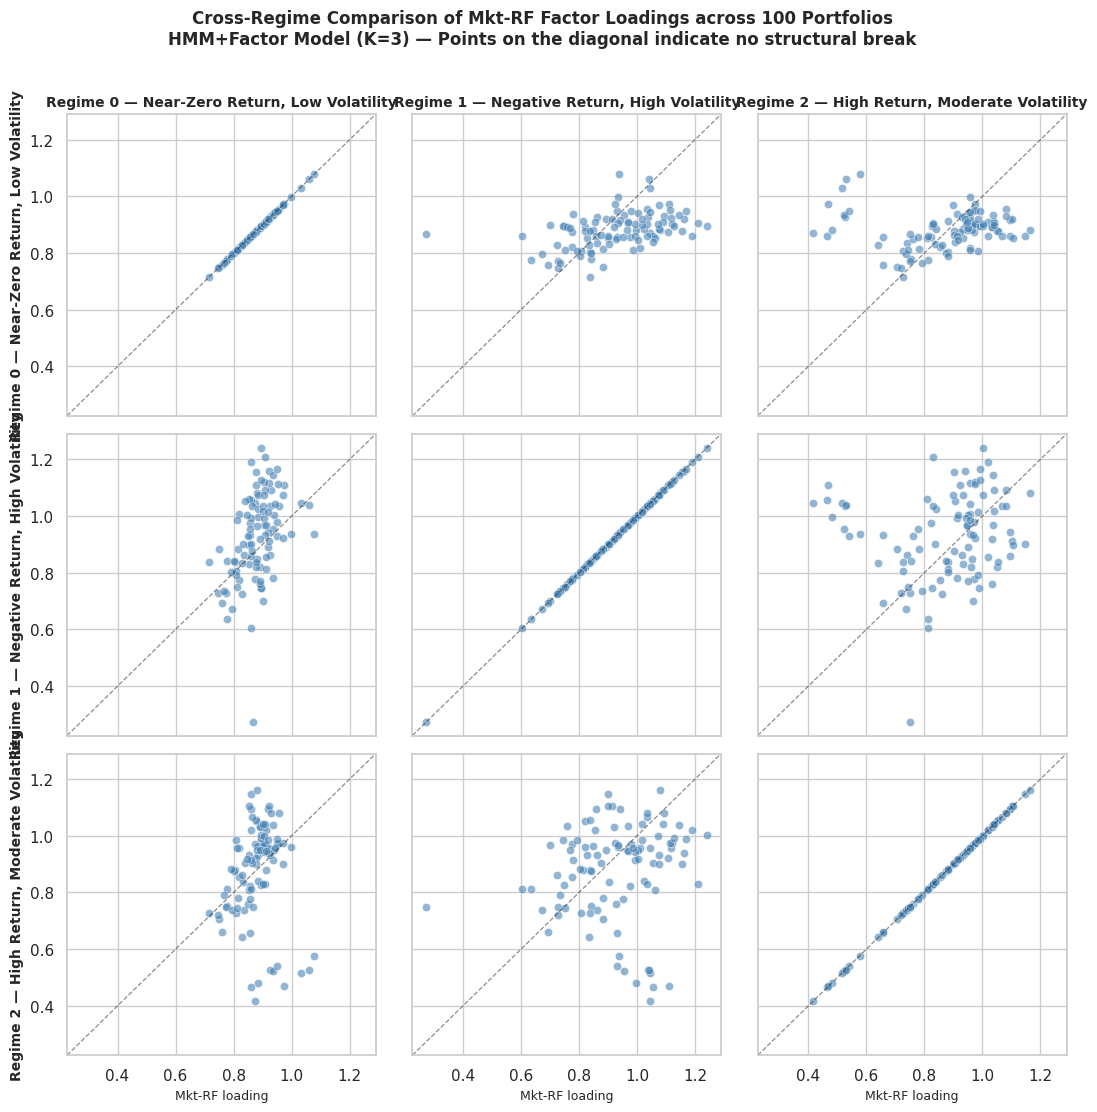

In [33]:
loadings_k3 = model_A["loadings"]   # (3, P, F)
mkt_idx = FACTOR_COLS.index("Mkt-RF")

L = [loadings_k3[k, :, mkt_idx] for k in range(3)]

# Rearrange labels prema stats_df (sortiranom po mean_mkt)
regime_labels = {
    int(stats_df.index[0]): "Regime 2 — High Return, Moderate Volatility",
    int(stats_df.index[1]): "Regime 1 — Negative Return, High Volatility",
    int(stats_df.index[2]): "Regime 0 — Near-Zero Return, Low Volatility",
}
names = [regime_labels.get(k, f"Regime {k}") for k in range(3)]

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

g_min = np.min(L) - 0.05 * (np.max(L) - np.min(L))
g_max = np.max(L) + 0.05 * (np.max(L) - np.min(L))

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        sns.scatterplot(x=L[j], y=L[i], color="steelblue",
                        alpha=0.6, s=35, edgecolor="white", ax=ax)
        ax.plot([g_min, g_max], [g_min, g_max], "k--", lw=0.9, alpha=0.5)
        ax.set_xlim(g_min, g_max)
        ax.set_ylim(g_min, g_max)
        if i == 0:
            ax.set_title(names[j], fontsize=10, fontweight="bold")
        if j == 0:
            ax.set_ylabel(names[i], fontsize=10, fontweight="bold")
        else:
            ax.set_yticklabels([])
        if i != 2:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Mkt-RF loading", fontsize=9)

plt.suptitle(
    "Cross-Regime Comparison of Mkt-RF Factor Loadings across 100 Portfolios\n"
    "HMM+Factor Model (K=3) — Points on the diagonal indicate no structural break",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

In [ ]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
# https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
# https://huggingface.co/blog/NormalUhr/kl-divergence-estimator-rl-llm
# http://joschu.net/blog/kl-approx.html